SARIMAX

NaNs in ts: 0
NaNs in exog:
 weekday       0
is_weekend    0
month         0
dtype: int64
Train length: 1438
Test length : 289


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                     
Dep. Variable:            Tagesumsatz Restaurant   No. Observations:                 1438
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -13765.987
Date:                           Sun, 30 Nov 2025   AIC                          27547.975
Time:                                   10:24:52   BIC                          27590.104
Sample:                                        0   HQIC                         27563.706
                                          - 1438                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
weekday      884.9900    137.120      6.454      0.000     616.240    1153.740
is_weekend  1701.0586    581.920      2.923

c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


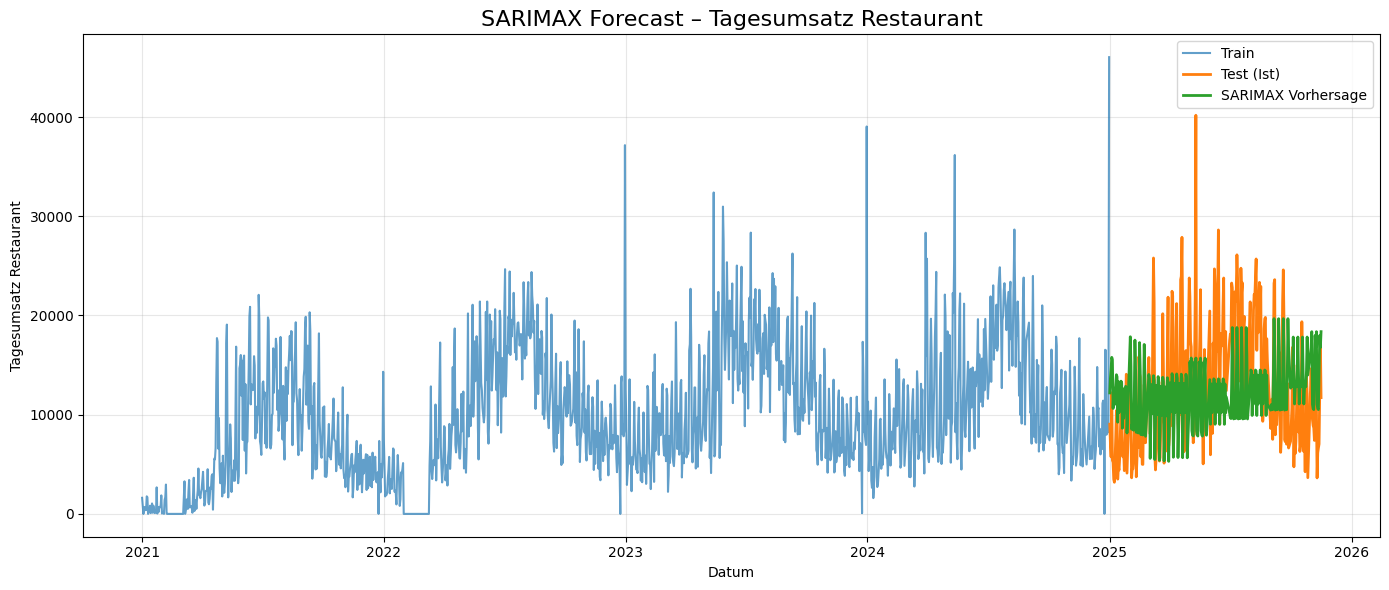

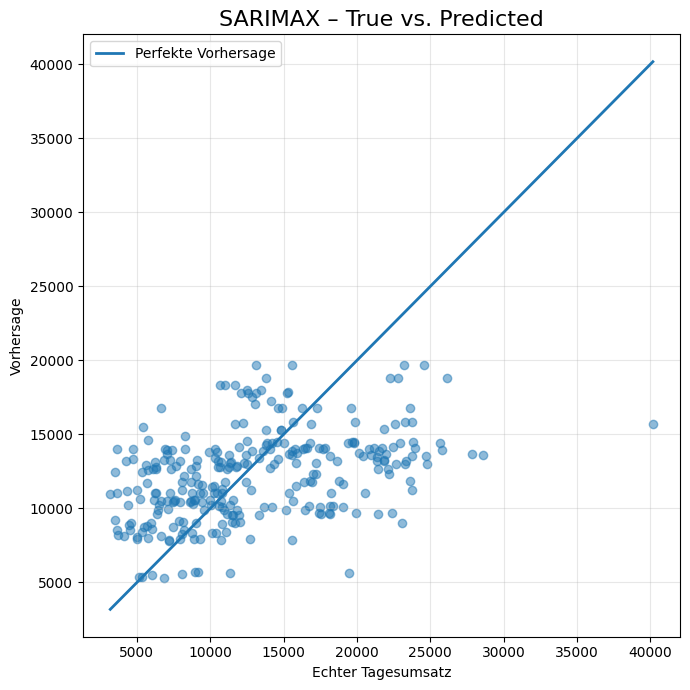

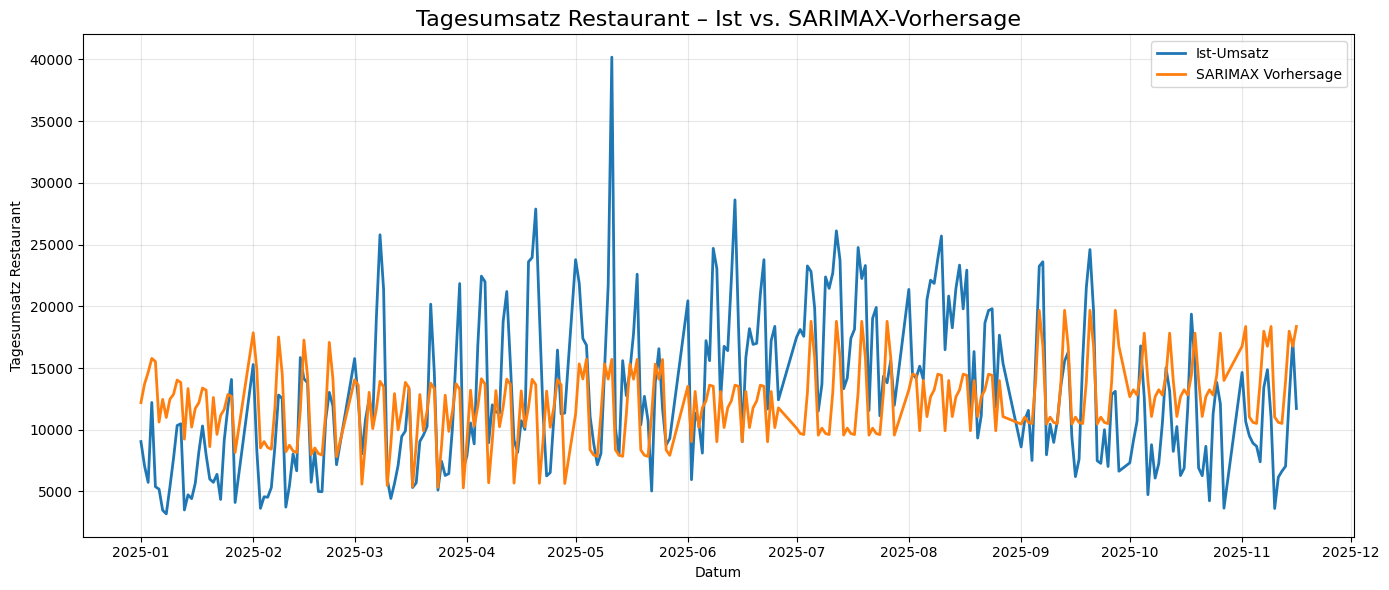

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1) Dataset laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# 2) Zielzeitreihe
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# 3) Exogene Variablen jetzt aus dem Index der Zeitreihe bauen
exog = pd.DataFrame(index=ts.index)
exog["weekday"] = exog.index.weekday              # 0=Mon ... 6=Son
exog["is_weekend"] = (exog["weekday"] >= 5).astype(int)
exog["month"] = exog.index.month

# Terrasse (falls vorhanden) sauber auf tägliche Frequenz bringen
if "Terrasse" in df.columns:
    terrasse_series = df.set_index("Datum")["Terrasse"]
    terrasse_series = terrasse_series.asfreq("D")
    terrasse_series = pd.to_numeric(terrasse_series, errors="coerce")
    terrasse_series = terrasse_series.ffill().bfill()
    exog["Terrasse"] = terrasse_series
else:
    # wenn nicht vorhanden, ignorieren wir sie einfach
    pass

# Inf in NaN umwandeln und dann alles füllen (zur Sicherheit)
exog = exog.replace([np.inf, -np.inf], np.nan)
exog = exog.ffill().bfill()

print("NaNs in ts:", ts.isna().sum())
print("NaNs in exog:\n", exog.isna().sum())

# 4) Train / Test Split
split_date = pd.Timestamp("2025-01-01")
train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

exog_train = exog.loc[train.index]
exog_test  = exog.loc[test.index]

print("Train length:", len(train))
print("Test length :", len(test))

# Sicherheitscheck
assert not np.isnan(exog_train.values).any(), "exog_train hat noch NaNs!"
assert not np.isnan(exog_test.values).any(), "exog_test hat noch NaNs!"

# 5) SARIMAX-Modell (SARIMA + exogene Variablen)
order = (1, 0, 1)
seasonal_order = (1, 1, 1, 7)   # Wochensaisonalität

model = SARIMAX(
    train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=True
)

model_fit = model.fit(disp=False)
print(model_fit.summary())

# 6) Forecast für Testperiode
forecast_res = model_fit.get_forecast(steps=len(test), exog=exog_test)
forecast = forecast_res.predicted_mean

# 7) METRIKEN
mse  = mean_squared_error(test, forecast)
rmse = mse ** 0.5
r2   = r2_score(test, forecast)
mae  = mean_absolute_error(test, forecast)

# Naive Baseline: Vortag
y_naive = test.shift(1).bfill()
mse_naive = mean_squared_error(test, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(test, forecast)

print("\n--- METRIKEN (SARIMAX) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# 8) Plot: Train, Test, Forecast
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (Ist)", linewidth=2)
plt.plot(test.index, forecast, label="SARIMAX Vorhersage", linewidth=2)

plt.title("SARIMAX Forecast – Tagesumsatz Restaurant", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Scatter: True vs Predicted
plt.figure(figsize=(7,7))
plt.scatter(test.values, forecast.values, alpha=0.5)

min_val = min(test.min(), forecast.min())
max_val = max(test.max(), forecast.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("SARIMAX – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10) Kompakter Test-Plot: Ist vs. Vorhersage
results_sarimax = pd.DataFrame({
    "Datum": test.index,
    "Ist": test.values,
    "Vorhersage": forecast.values
})

plt.figure(figsize=(14,6))
plt.plot(results_sarimax["Datum"], results_sarimax["Ist"],
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_sarimax["Datum"], results_sarimax["Vorhersage"],
         label="SARIMAX Vorhersage", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. SARIMAX-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


SARIMA Model

Train length: 1461
Test length : 320


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                     
Dep. Variable:            Tagesumsatz Restaurant   No. Observations:                 1461
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -13984.949
Date:                           Sun, 30 Nov 2025   AIC                          27979.898
Time:                                   10:25:26   BIC                          28006.308
Sample:                               01-01-2021   HQIC                         27989.752
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9804      0.007    140.716      0.000       0.967       0.994
ma.L1         -0.7433      0.018    -40.309

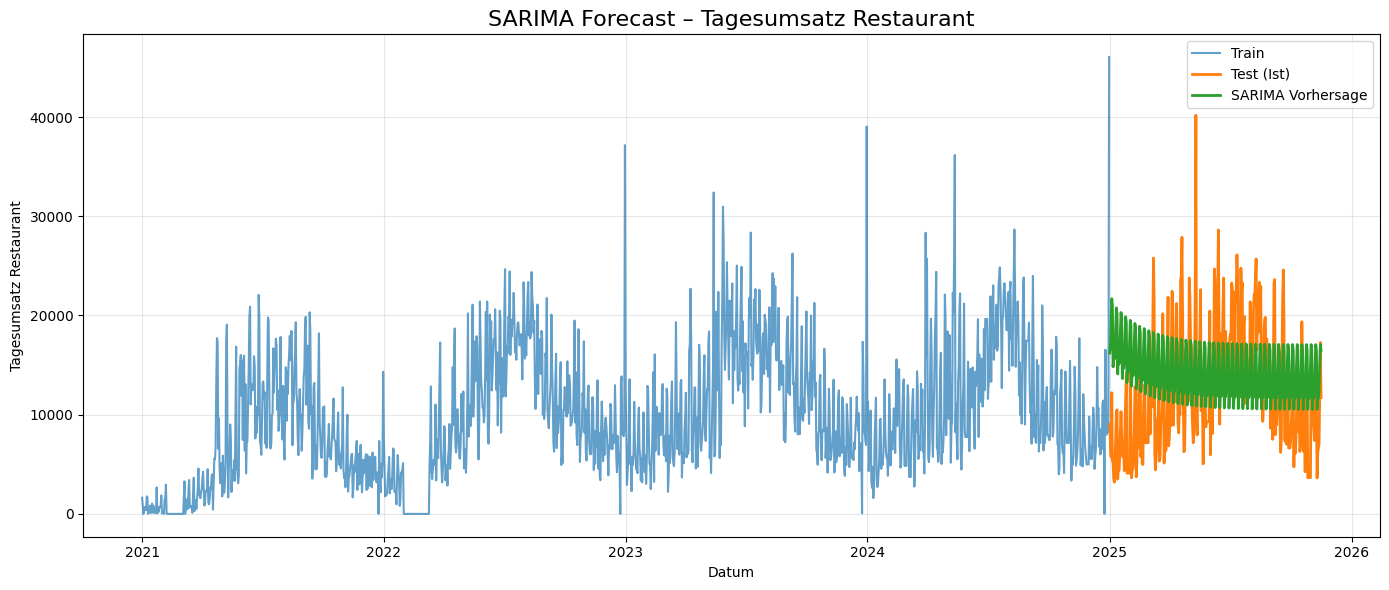

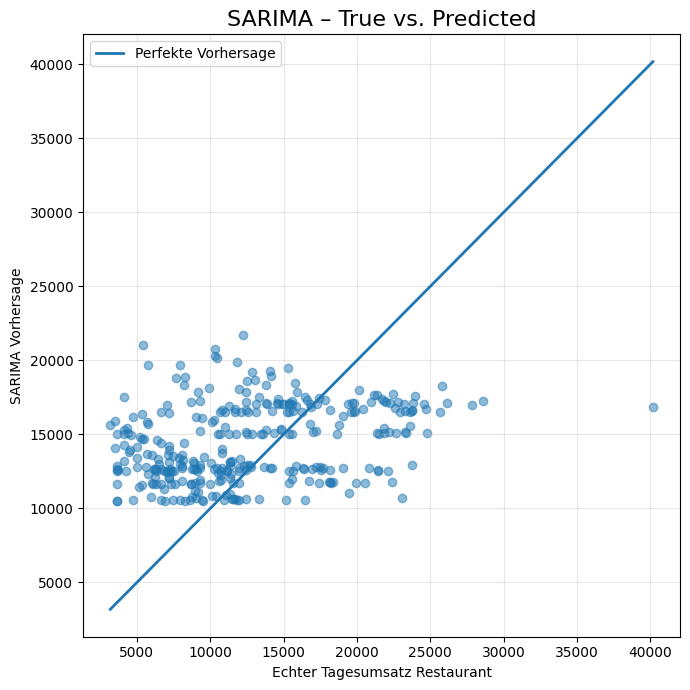

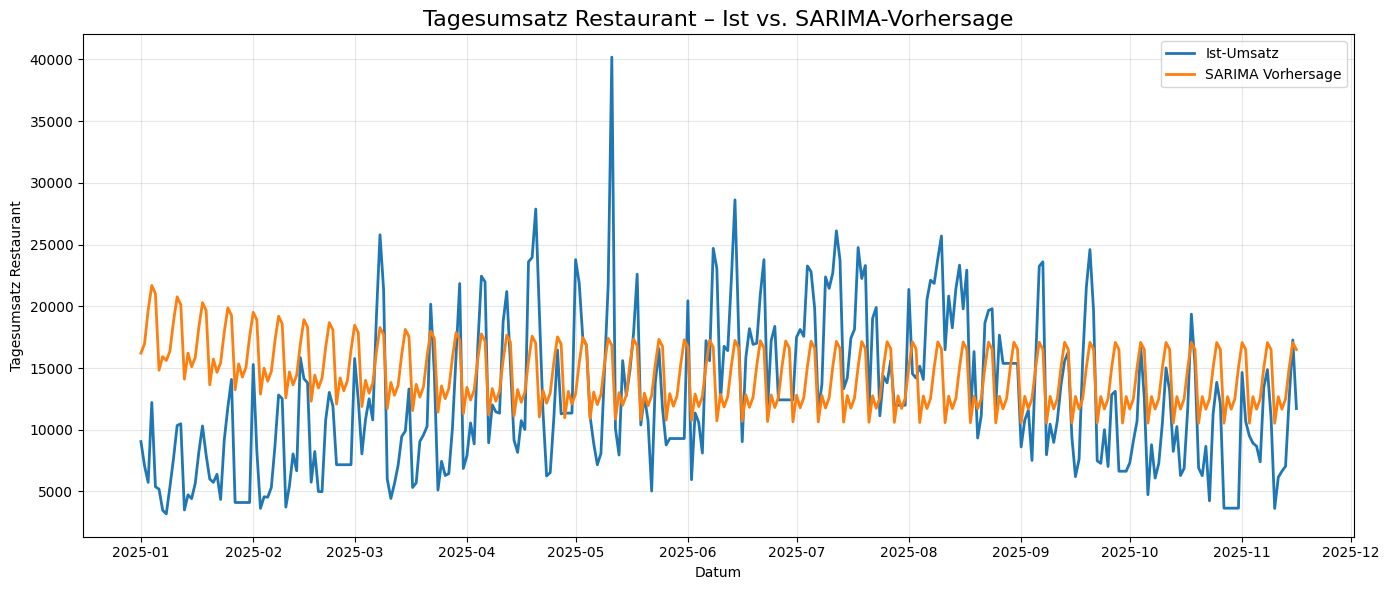

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1) Dataset laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# 2) Univariate Zeitreihe (Target = Tagesumsatz Restaurant)
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# tägliche Frequenz setzen und Lücken füllen
ts = ts.asfreq("D")
ts = ts.ffill().bfill()   # NaNs nach vorne und hinten füllen

# 3) Train / Test Split (zeitbasiert)
split_date = pd.Timestamp("2025-01-01")

train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# 4) SARIMA-Modell fitten
# Einfacher, stabiler Startpunkt:
# order = (p,d,q), seasonal_order = (P,D,Q,s) mit s=7 (wöchentliche Saisonalität)
order = (1, 0, 1)
seasonal_order = (1, 1, 1, 7)

model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=True
)

model_fit = model.fit(disp=False)
print(model_fit.summary())

# 5) Forecast über Testperiode
forecast_res = model_fit.get_forecast(steps=len(test))
forecast = forecast_res.predicted_mean

# 6) Evaluation
# Basic metrics
mse  = mean_squared_error(test, forecast)
rmse = mse ** 0.5
r2   = r2_score(test, forecast)
mae  = mean_absolute_error(test, forecast)

# Relative MSE vs naive (Lag-1) baseline
y_naive = test.shift(1).bfill()  # naive forecast: yesterday's value
mse_naive = mean_squared_error(test, y_naive)
relative_MSE = mse / mse_naive

# MAPE
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(test, forecast)

print("\n--- METRICS ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")


# 7) Plot: Train, Test (Ist) und Forecast
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (Ist)", linewidth=2)
plt.plot(test.index, forecast, label="SARIMA Vorhersage", linewidth=2)

plt.title("SARIMA Forecast – Tagesumsatz Restaurant", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8) Scatter Plot: True vs Forecast
plt.figure(figsize=(7,7))
plt.scatter(test.values, forecast.values, alpha=0.5)

x_min = min(test.min(), forecast.min())
x_max = max(test.max(), forecast.max())
plt.plot([x_min, x_max], [x_min, x_max],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("SARIMA – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz Restaurant")
plt.ylabel("SARIMA Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Zeitreihen-Plot: Ist vs. Vorhersage (nur Testperiode)

results_sarima = pd.DataFrame({
    "Datum": test.index,
    "Ist": test.values,
    "Vorhersage": forecast.values
})

plt.figure(figsize=(14,6))
plt.plot(results_sarima["Datum"], results_sarima["Ist"], 
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_sarima["Datum"], results_sarima["Vorhersage"], 
         label="SARIMA Vorhersage", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. SARIMA-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ARIMA Model

Train length: 1438
Test length : 289


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     Tagesumsatz Restaurant   No. Observations:                 1438
Model:                     ARIMA(5, 1, 3)   Log Likelihood              -13928.028
Date:                    Sun, 30 Nov 2025   AIC                          27874.055
Time:                            10:25:44   BIC                          27921.488
Sample:                                 0   HQIC                         27891.764
                                   - 1438                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0929      0.048      1.918      0.055      -0.002       0.188
ar.L2         -0.8223      0.045    -18.463      0.000      -0.910      -0.735
ar.L3         -0.007

c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


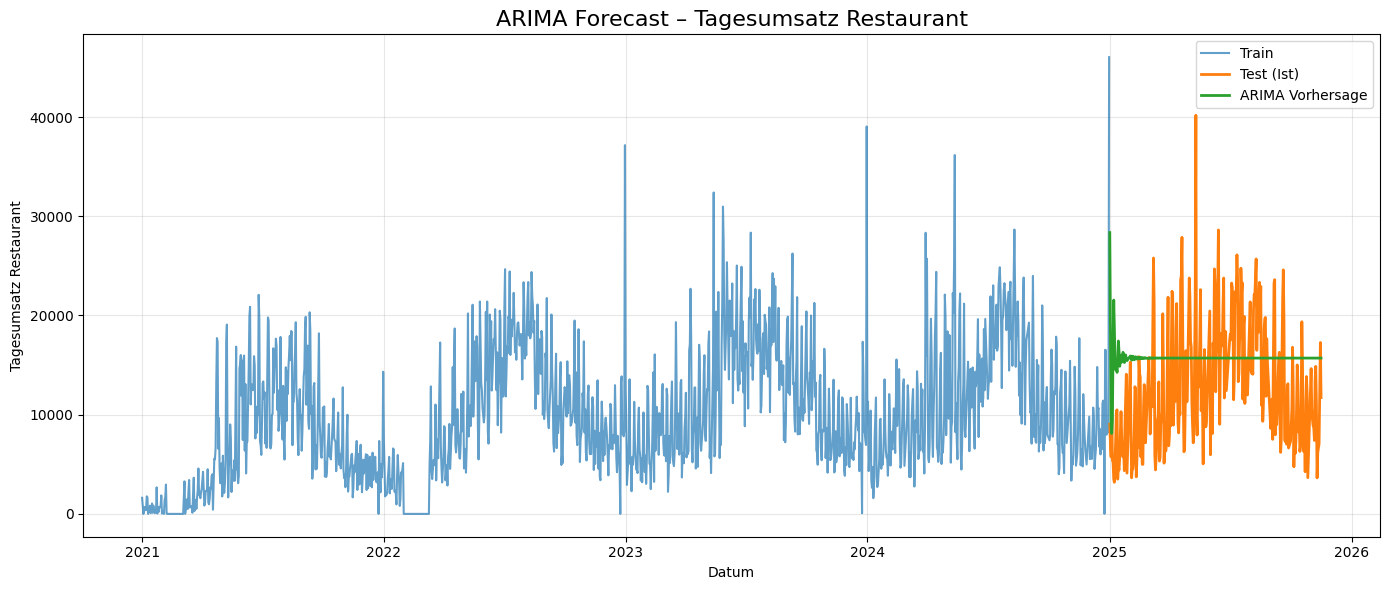

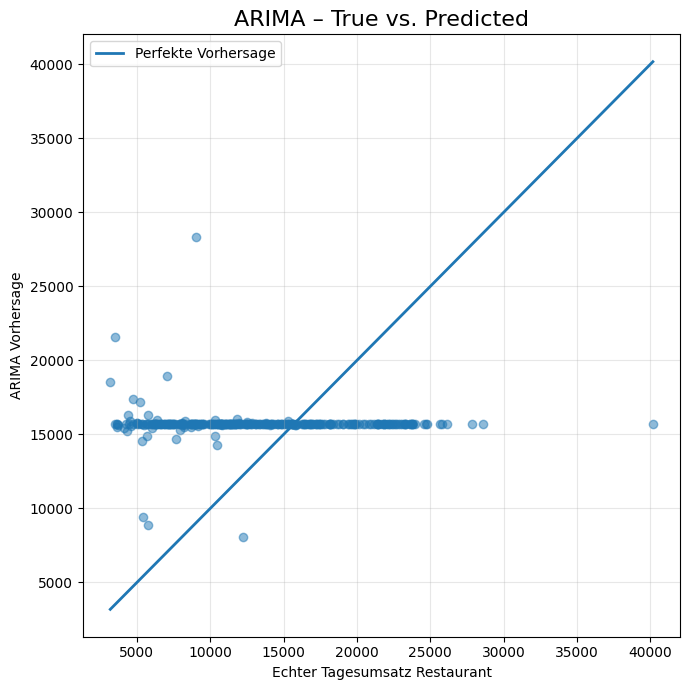

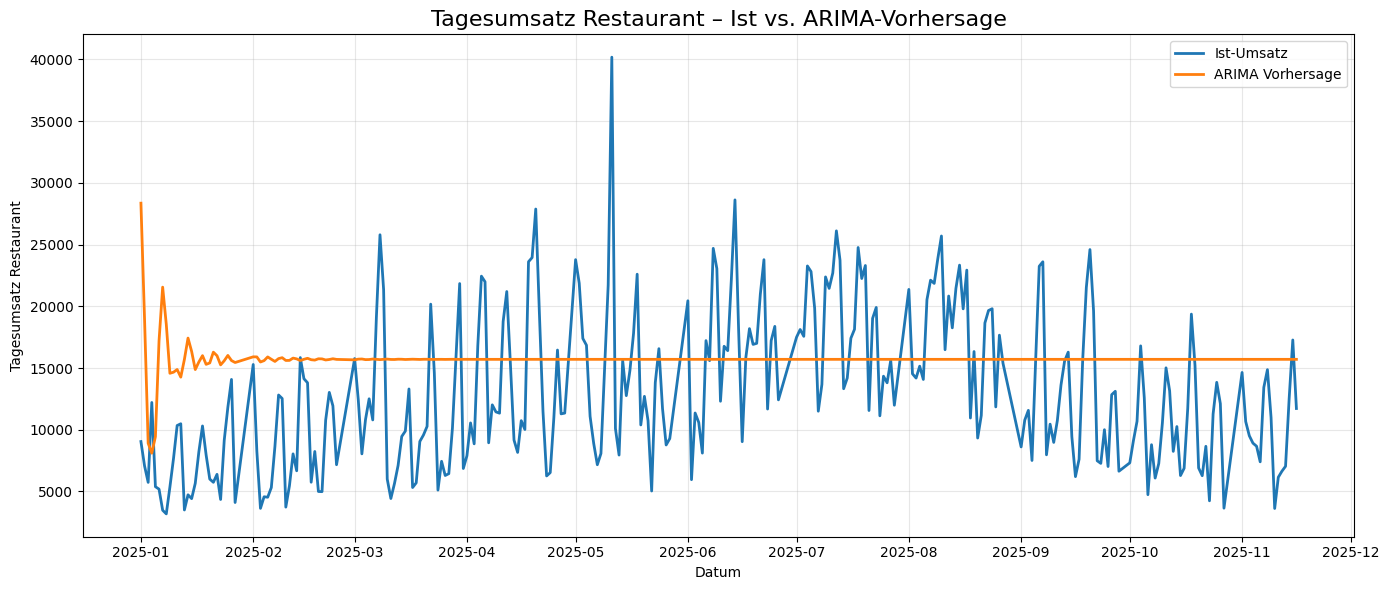

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

# 1) Dataset laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# 2) Univariate Zeitreihe für ARIMA (Target = Tagesumsatz Restaurant)
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# 3) Train / Test Split (zeitbasiert)
split_date = pd.Timestamp("2025-01-01")

train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# 4) ARIMA-Modell fitten
order = (5, 1, 3)   # kann man später noch tunen

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

# 5) Forecast über Testperiode
forecast = model_fit.forecast(steps=len(test))

# 6) Evaluation
mse  = mean_squared_error(test, forecast)
rmse = mse ** 0.5
r2   = r2_score(test, forecast)

print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

# 7) Plot: Train, Test (Ist) und Forecast
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (Ist)", linewidth=2)
plt.plot(test.index, forecast, label="ARIMA Vorhersage", linewidth=2)

plt.title("ARIMA Forecast – Tagesumsatz Restaurant", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8) Scatter Plot: True vs Forecast
plt.figure(figsize=(7,7))
plt.scatter(test.values, forecast.values, alpha=0.5)
plt.plot([min(test), max(test)], [min(test), max(test)],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("ARIMA – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz Restaurant")
plt.ylabel("ARIMA Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Zeitreihen-Plot: Ist vs. Vorhersage (nur Testperiode, schön kompakt)

results_arima = pd.DataFrame({
    "Datum": test.index,
    "Ist": test.values,
    "Vorhersage": forecast.values
})

plt.figure(figsize=(14,6))
plt.plot(results_arima["Datum"], results_arima["Ist"], 
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_arima["Datum"], results_arima["Vorhersage"], 
         label="ARIMA Vorhersage", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. ARIMA-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()